# 常用第三方模块

除了内建的模块外，Python还有大量的第三方模块。

基本上，所有的第三方模块都会在[PyPI - the Python Package Index](https://pypi.org/)上注册，只要找到对应的模块名字，即可用pip安装。

此外，在安装第三方模块一节中，我们强烈推荐安装[Anaconda](https://www.anaconda.com/anaconda)，安装后，数十个常用的第三方模块就已经就绪，不用pip手动安装。

本章介绍常用的第三方模块。

## Pillow (PIL)

PIL：Python Imaging Library，已经是Python平台事实上的图像处理标准库了。PIL功能非常强大，但API却非常简单易用。

由于PIL仅支持到Python 2.7，加上年久失修，于是一群志愿者在PIL的基础上创建了兼容的版本，名字叫Pillow，支持最新Python 3.x，又加入了许多新特性，因此，我们可以直接安装使用Pillow。


### 安装Pillow

如果安装了Anaconda，Pillow就已经可用了。否则，需要在命令行下通过pip安装：

```bash
$ pip install pillow
```
如果遇到Permission denied安装失败，请加上sudo重试。


### 操作图像

来看看最常见的图像缩放操作，只需三四行代码：

In [ ]:
from PIL import Image

# 打开一个jpg图像文件，注意是当前路径:
im = Image.open('test.jpg')
# 获得图像尺寸:
w, h = im.size
print('Original image size: %sx%s' % (w, h))
# 缩放到50%:
im.thumbnail((w//2, h//2))
print('Resize image to: %sx%s' % (w//2, h//2))
# 把缩放后的图像用jpeg格式保存:
im.save('thumbnail.jpg', 'jpeg')

其他功能如切片、旋转、滤镜、输出文字、调色板等一应俱全。

比如，模糊效果也只需几行代码：

缩放：


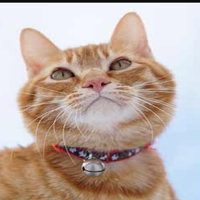

裁剪：


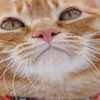

模糊滤镜：


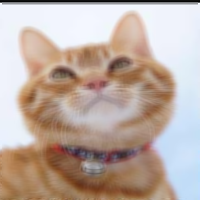

转RGBA/RGB：


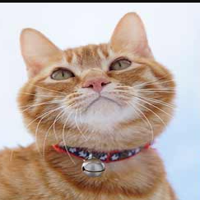

In [12]:
from PIL import Image, ImageFilter
from IPython.display import display

# 打开一个jpg图像文件，注意是当前路径:
im = Image.open('./res/image.png')

# 缩放
print("缩放：")
im = im.resize((200,200))
display(im)  # 直接渲染图片

# 裁剪 (左,上,右,下)
print("裁剪：")
crop_img = im.crop((50,50,150,150))
display(crop_img)  # 直接渲染图片

# 应用模糊滤镜:
print("模糊滤镜：")
im2 = im.filter(ImageFilter.BLUR)
# im2.save('blur.jpg', 'jpeg')
display(im2)  # 直接渲染图片

# 转RGBA/RGB
print("转RGBA/RGB：")
rgba = im.convert("RGBA")
display(rgba)  # 直接渲染图片

PIL的ImageDraw提供了一系列绘图方法，让我们可以直接绘图。比如要生成字母验证码图片：

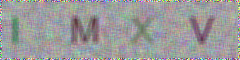

In [ ]:
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from IPython.display import display

import random

# 随机字母:
def rndChar():
    return chr(random.randint(65, 90))

# 随机颜色1:
def rndColor():
    return (random.randint(64, 255), random.randint(64, 255), random.randint(64, 255))

# 随机颜色2:
def rndColor2():
    return (random.randint(32, 127), random.randint(32, 127), random.randint(32, 127))

# 240 x 60:
width = 60 * 4
height = 60
image = Image.new('RGB', (width, height), (255, 255, 255))
# 创建Font对象:
# font = ImageFont.truetype('Arial.ttf', 36)
# 这是因为PIL无法定位到字体文件的位置，可以根据操作系统提供绝对路径 win+r:Fonts,然后将对应字体拖入运行框中可以看到路径
font = ImageFont.truetype('C:\Windows\Fonts\ARIAL.TTF', 36)
# 创建Draw对象:
draw = ImageDraw.Draw(image)
# 填充每个像素:
for x in range(width):
    for y in range(height):
        draw.point((x, y), fill=rndColor())
# 输出文字:
for t in range(4):
    draw.text((60 * t + 10, 10), rndChar(), font=font, fill=rndColor2())
# 模糊:
image = image.filter(ImageFilter.BLUR)
# image.save('code.jpg', 'jpeg')
display(image)  # 直接渲染图片

## requests

我们已经讲解了Python内置的urllib模块，用于访问网络资源。但是，它用起来比较麻烦，而且，缺少很多实用的高级功能。

更好的方案是使用requests。它是一个Python第三方库，处理URL资源特别方便。


### 安装requests

如果安装了Anaconda，requests就已经可用了。否则，需要在命令行下通过pip安装：


In [ ]:
! pip install requests

### 使用requests

要通过GET访问一个页面，只需要几行代码：

In [ ]:
import requests

r = requests.get('https://www.douban.com/') # 豆瓣首页

print(r.status_code)
print(r.text)
print(r.content)

418

b''


对于带参数的URL，传入一个dict作为params参数：

In [21]:
r = requests.get('https://liaoxuefeng.com/books/python/reg-exp/index.html', params={'q': 'python', 'cat': '1001'})
print(r.url)

https://liaoxuefeng.com/books/python/reg-exp/index.html?q=python&cat=1001


requests自动检测编码，可以使用encoding属性查看：

In [22]:
print(r.encoding)

ISO-8859-1


requests的方便之处还在于，对于特定类型的响应，例如JSON，可以直接获取：

In [ ]:
print(r.json())

需要传入HTTP Header时，我们传入一个dict作为headers参数：

In [23]:
r = requests.get('https://www.douban.com/', headers={'User-Agent': 'Mozilla/5.0 (iPhone; CPU iPhone OS 11_0 like Mac OS X) AppleWebKit'})
r.text

'\n\n<!DOCTYPE html>\n<html itemscope itemtype="http://schema.org/WebPage" class="ua-mobile ">\n  <head>\n      <meta charset="UTF-8">\n      <title>豆瓣(手机版)</title>\n      <meta name=\'360_ssp_verify\' content=\'ee7f73d3af2299c1c780fe7f3a657c51\' />\n      <meta name="google-site-verification" content="ok0wCgT20tBBgo9_zat2iAcimtN4Ftf5ccsh092Xeyw" />\n      <meta name="viewport" content="width=device-width, height=device-height, user-scalable=no, initial-scale=1.0, minimum-scale=1.0, maximum-scale=1.0">\n      <meta name="format-detection" content="telephone=no">\n      <meta name="description" content="读书、看电影、涨知识、学穿搭...，加入兴趣小组，获得达人们的高质量生活经验，找到有相同爱好的小伙伴。">\n      <meta name="keywords" content="豆瓣,手机豆瓣,豆瓣手机版,豆瓣电影,豆瓣读书,豆瓣同城">\n      <link rel="canonical" href="\nhttps://m.douban.com/">\n      <link href="https://img1.doubanio.com/f/talion/ccac7805cc6b1c2680aff3b58d94ec133f640df6/css/card/base.css" rel="stylesheet">\n      \n<script>\n  var saveKey = \'_t_splash\'\n  var day = 3\n  if (Dat

要发送POST请求，只需要把get()方法变成post()，然后传入data参数作为POST请求的数据：



In [ ]:
r = requests.post('https://accounts.douban.com/login', data={'form_email': 'abc@example.com', 'form_password': '123456'})

requests默认使用application/x-www-form-urlencoded对POST数据编码。如果要传递JSON数据，可以直接传入json参数：



In [ ]:
params = {'key': 'value'}
r = requests.post(url, json=params) # 内部自动序列化为JSON

类似的，上传文件需要更复杂的编码格式，但是requests把它简化成files参数：

In [ ]:
upload_files = {'file': open('report.xls', 'rb')}
r = requests.post(url, files=upload_files)

在读取文件时，注意务必使用'rb'即二进制模式读取，这样获取的bytes长度才是文件的长度。

把post()方法替换为put()，delete()等，就可以以PUT或DELETE方式请求资源。

## chardet

字符串编码一直是令人非常头疼的问题，尤其是我们在处理一些不规范的第三方网页的时候。虽然Python提供了Unicode表示的str和bytes两种数据类型，并且可以通过encode()和decode()方法转换，但是，在不知道编码的情况下，对bytes做decode()不好做。

对于未知编码的bytes，要把它转换成str，需要先“猜测”编码。猜测的方式是先收集各种编码的特征字符，根据特征字符判断，就能有很大概率“猜对”。

当然，我们肯定不能从头自己写这个检测编码的功能，这样做费时费力。chardet这个第三方库正好就派上了用场。用它来检测编码，简单易用。

### 安装chardet

如果安装了Anaconda，chardet就已经可用了。否则，需要在命令行下通过pip安装：

In [24]:
! pip install chardet

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/941.9 kB ? eta -:--:--
     ------ ------------------------------ 174.1/941.9 kB 10.2 MB/s eta 0:00:01
     --------- ---------------------------- 235.5/941.9 kB 3.6 MB/s eta 0:00:01
     ---------------- --------------------- 419.8/941.9 kB 3.3 MB/s eta 0:00:01
     --------------------- ---------------- 522.2/941.9 kB 3.0 MB/s eta 0:00:01
     ---------------------------- --------- 696.3/941.9 kB 3.1 MB/s eta 0:00:01
     -------------------------------- ----- 809.0/941.9 kB 3.0 MB/s eta 0:00:01
     ---------------------------------- --- 849.9/941.9 kB 3.0 MB/s eta 0:00:01
     -------------------------------------- 941.9/941.9 kB 2.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 使用chardet

当我们拿到一个bytes时，就可以对其检测编码。用chardet检测编码，只需要一行代码：

In [26]:
import chardet

chardet.detect(b'Hello, world!')

{'encoding': 'ascii',
 'confidence': 1.0,
 'language': 'pl',
 'mime_type': 'text/plain'}

检测出的编码是ascii，注意到还有个confidence字段，表示检测的概率是1.0（即100%）。

我们来试试检测GBK编码的中文：

In [27]:
data = '离离原上草，一岁一枯荣'.encode('gbk')
chardet.detect(data)


{'encoding': 'GB18030',
 'confidence': 0.2634659761620448,
 'language': 'zh',
 'mime_type': 'text/plain'}

检测的编码是GB18030，注意到GBK是GB18030的超集，两者是同一种编码，检测正确的概率是26%，language字段指出的语言是'Chinese'。

对UTF-8编码进行检测：

In [28]:
data = '离离原上草，一岁一枯荣'.encode('utf-8') 
chardet.detect(data)

{'encoding': 'utf-8',
 'confidence': 0.99,
 'language': 'zh',
 'mime_type': 'text/plain'}

我们再试试对日文进行检测：

In [29]:
data = '最新の主要ニュース'.encode('euc-jp')
chardet.detect(data)

{'encoding': 'EUC-JP',
 'confidence': 0.43039773535090303,
 'language': 'ja',
 'mime_type': 'text/plain'}

可见，用chardet检测编码，使用简单。获取到编码后，再转换为str，就可以方便后续处理。

chardet支持检测的编码列表请参考官方文档[Supported encodings](https://chardet.readthedocs.io/en/latest/supported-encodings.html)。

## psutil

用Python来编写脚本简化日常的运维工作是Python的一个重要用途。在Linux下，有许多系统命令可以让我们时刻监控系统运行的状态，如ps，top，free等等。要获取这些系统信息，Python可以通过subprocess模块调用并获取结果。但这样做显得很麻烦，尤其是要写很多解析代码。

在Python中获取系统信息的另一个好办法是使用psutil这个第三方模块。顾名思义，psutil = process and system utilities，它不仅可以通过一两行代码实现系统监控，还可以跨平台使用，支持Linux／UNIX／OSX／Windows等，是系统管理员和运维小伙伴不可或缺的必备模块。

### 安装psutil

如果安装了Anaconda，psutil就已经可用了。否则，需要在命令行下通过pip安装：

In [ ]:
! pip install psutil

获取CPU信息
我们先来获取CPU的信息：

In [31]:
import psutil

print(psutil.cpu_count()) # CPU逻辑数量
print(psutil.cpu_count(logical=False)) # CPU物理核心


4
4


统计CPU的用户／系统／空闲时间：

In [32]:
psutil.cpu_times()

scputimes(user=540172.890625, system=313012.828125, idle=1591106.71875, interrupt=4800.234375, dpc=2440.9375)

再实现类似top命令的CPU使用率，每秒刷新一次，累计10次：

In [34]:
for x in range(10):
    print(psutil.cpu_percent(interval=1, percpu=True))

[72.3, 67.2, 82.8, 78.5]
[72.7, 70.3, 75.4, 75.4]
[39.1, 53.1, 59.4, 67.2]
[58.8, 50.8, 52.3, 47.7]
[45.3, 39.1, 53.1, 64.1]
[40.9, 32.8, 39.1, 54.7]
[62.1, 76.6, 81.2, 73.4]
[65.7, 57.8, 64.6, 78.1]
[32.8, 32.8, 64.1, 46.9]
[31.2, 45.3, 46.9, 62.5]


### 获取内存信息
使用psutil获取物理内存和交换内存信息，分别使用：

In [ ]:
print(psutil.virtual_memory()) # 物理内存,返回的是字节为单位的整数

print(psutil.swap_memory()) # 交换内存

svmem(total=34263375872, available=11759042560, percent=65.7, used=22504333312, free=11759042560)
sswap(total=15569256448, used=1058541568, free=14510714880, percent=6.8, sin=0, sout=0)


### 获取磁盘信息

可以通过psutil获取磁盘分区、磁盘使用率和磁盘IO信息：

In [37]:
print(psutil.disk_partitions()) # 磁盘分区信息
print(psutil.disk_usage('C:\\')) # 磁盘使用情况
print(psutil.disk_io_counters()) # 磁盘IO信息


[sdiskpart(device='C:\\', mountpoint='C:\\ProgramData\\Microsoft\\Windows\\Containers\\BaseImages\\55c4e378-2845-423c-83f6-b05d8083fd1e\\BaseLayer\\', fstype='NTFS', opts='rw'), sdiskpart(device='C:\\', mountpoint='C:\\', fstype='NTFS', opts='rw,fixed'), sdiskpart(device='D:\\', mountpoint='D:\\', fstype='NTFS', opts='rw,fixed'), sdiskpart(device='E:\\', mountpoint='E:\\', fstype='', opts='cdrom')]
sdiskusage(total=239338516480, used=226048282624, free=13290233856, percent=94.4)
sdiskio(read_count=5411618, write_count=10645109, read_bytes=305118457856, write_bytes=466848686080, read_time=16907, write_time=17952)


### 获取网络信息

psutil可以获取网络接口和网络连接信息：

In [39]:
print(psutil.net_io_counters()) # 获取网络读写字节／包的个数
print(psutil.net_if_addrs()) # 获取网络接口信息
print(psutil.net_if_stats()) # 获取网络接口状态
print(psutil.net_connections()) # 获取网络连接信息


snetio(bytes_sent=4208774797, bytes_recv=15155550498, packets_sent=20066579, packets_recv=27350067, errin=0, errout=0, dropin=0, dropout=0)
{'以太网 2': [snicaddr(family=<AddressFamily.AF_LINK: -1>, address='8C-EC-4B-61-FE-16', netmask=None, broadcast=None, ptp=None), snicaddr(family=<AddressFamily.AF_INET: 2>, address='10.200.110.79', netmask='255.255.255.0', broadcast=None, ptp=None), snicaddr(family=<AddressFamily.AF_INET6: 23>, address='fe80::9e68:f23f:9821:5d94', netmask=None, broadcast=None, ptp=None)], 'WLAN 2': [snicaddr(family=<AddressFamily.AF_LINK: -1>, address='9C-30-5B-EF-C0-57', netmask=None, broadcast=None, ptp=None), snicaddr(family=<AddressFamily.AF_INET: 2>, address='169.254.96.64', netmask='255.255.0.0', broadcast=None, ptp=None), snicaddr(family=<AddressFamily.AF_INET6: 23>, address='fe80::c36f:1a7b:dc62:35c5', netmask=None, broadcast=None, ptp=None)], '本地连接* 11': [snicaddr(family=<AddressFamily.AF_LINK: -1>, address='1E-30-5B-EF-C0-57', netmask=None, broadcast=None, p

### 获取进程信息

通过psutil可以获取到所有进程的详细信息

In [40]:
# 安装（没装先执行）
# !pip install psutil
import psutil
import os

# 1. 获取全部进程PID
all_pids = psutil.pids()
print("所有进程PID列表(前10个):", all_pids[:10])

# 2. 获取当前Python进程PID
current_pid = os.getpid()
p = psutil.Process(current_pid)
print(f"\n当前进程PID: {current_pid}")

# 进程各类信息
print("进程名称:", p.name())
print("exe路径:", p.exe())
print("工作目录:", p.cwd())
print("启动命令行:", p.cmdline())
print("父进程PID:", p.ppid())
print("父进程对象:", p.parent())
print("子进程列表:", p.children())
print("进程状态:", p.status())
print("运行用户名:", p.username())
print("创建时间戳:", p.create_time())

try:
    print("绑定终端:", p.terminal())
except Exception:
    print("绑定终端: 无(非终端启动)")

print("CPU占用时间:", p.cpu_times())
print("内存信息(rss/vms):", p.memory_info())
print("打开的文件:", p.open_files())
print("网络连接:", p.connections())
print("线程总数:", p.num_threads())
print("线程详情:", p.threads())
print("环境变量(部分):", dict(list(p.environ().items())[:5]))

# ⚠️ 慎用！p.terminate() 会直接杀掉当前jupyter进程
# p.terminate()

所有进程PID列表(前10个): [0, 4, 8, 56, 76, 116, 432, 520, 536, 644]

当前进程PID: 17256
进程名称: python.exe
exe路径: D:\soft\Python311\python.exe
工作目录: d:\githubRepository\AntHubTC.github.io\python\jupterDoc
启动命令行: ['d:\\soft\\Python311\\python.exe', '-m', 'ipykernel_launcher', '--f=c:\\Users\\Administrator\\AppData\\Roaming\\jupyter\\runtime\\kernel-v32652722bc2978d0abc0c708206149c5f8841e0c5.json']
父进程PID: 18188
父进程对象: psutil.Process(pid=18188, name='Trae CN.exe', status='running', started='2026-06-04 14:51:46')
子进程列表: [psutil.Process(pid=26344, name='conhost.exe', status='running', started='16:18:07')]
进程状态: running
运行用户名: DESKTOP-KDNIR2G\Administrator
创建时间戳: 1780647487.2789526
绑定终端: 无(非终端启动)
CPU占用时间: pcputimes(user=2.8125, system=3.765625, children_user=0.0, children_system=0.0)
内存信息(rss/vms): pmem(rss=130904064, vms=143388672, num_page_faults=63293, peak_wset=146329600, wset=130904064, peak_paged_pool=259528, paged_pool=236528, peak_nonpaged_pool=1365632, nonpaged_pool=113752, pagefile=143388672, p

C:\Users\Administrator\AppData\Local\Temp\ipykernel_17256\2473895055.py:35: DeprecationWarning: connections() is deprecated and will be removed; use net_connections() instead
  print("网络连接:", p.connections())


> psutil使得Python程序获取系统信息变得易如反掌。

psutil还可以获取用户信息、Windows服务等很多有用的系统信息，具体请参考psutil的官网：https://github.com/giampaolo/psutil